In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
df = pd.read_csv("Sample - Superstore.csv" , encoding="latin1")

In [15]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [18]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [20]:
df.shape

(9994, 21)

In [23]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [24]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [26]:
df.duplicated().sum()

np.int64(0)

In [27]:
#Order Date and Ship Date are stored as text.We need to convert them into dates.
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

In [28]:
# Instead of repeatedly extracting information from the date, we'll create new columns.
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month_name()
df["Quarter"] = df["Order Date"].dt.quarter

### Business Question 1 : which Region Generates the Highest Sales?

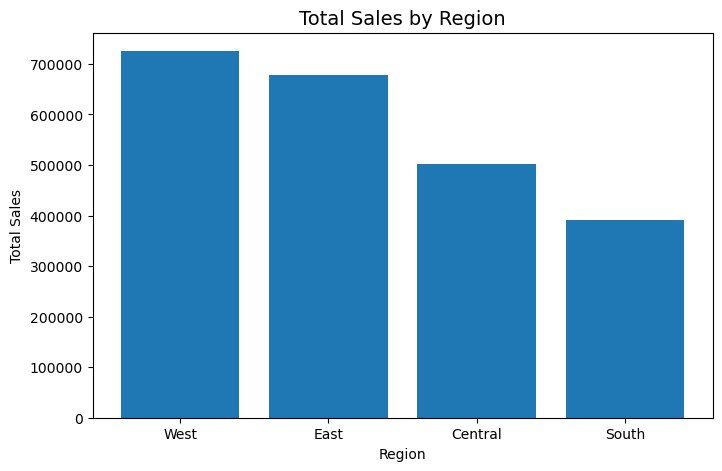

In [30]:
region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))

plt.bar(
    region_sales.index,
    region_sales.values
)

plt.title("Total Sales by Region", fontsize=14)
plt.xlabel("Region")
plt.ylabel("Total Sales")

plt.show()

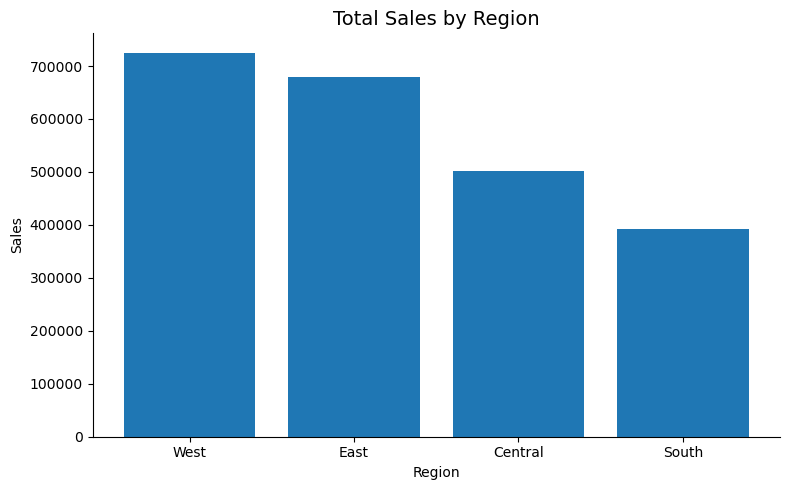

In [33]:
 # Improved data ink ratio
region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))

plt.bar(region_sales.index, region_sales.values)

plt.title("Total Sales by Region", fontsize=14)
plt.xlabel("Region")
plt.ylabel("Sales")

sns.despine()

plt.tight_layout()

plt.show()

#### Business Insights
 The West region generated the highest sales among all regions, while the South region contributed the least revenue.
#### Business Recommendation
The company should continue investing in the West region because it generates strong revenue. For the South region, management should investigate the reasons for lower sales and consider promotional campaigns or product expansion.

### Business Question 2 : Which Product Category Generates the Highest Sales?

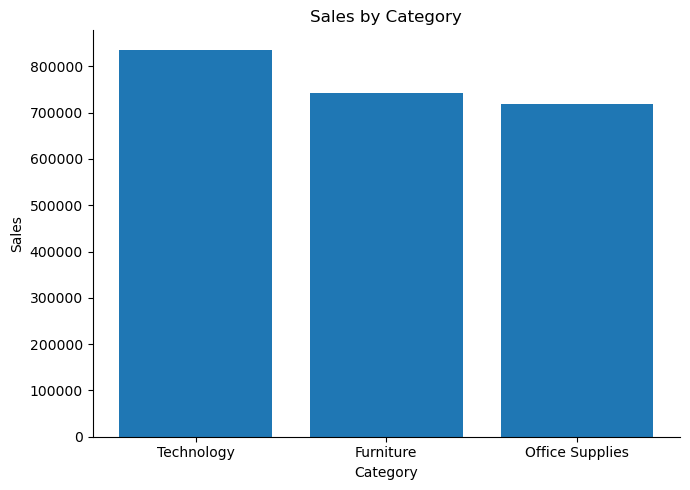

In [34]:
category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(7,5))

plt.bar(
    category_sales.index,
    category_sales.values
)

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")

sns.despine()

plt.tight_layout()

plt.show()

#### Business Insight
 Technology generated the highest sales, followed by Furniture, while Office Supplies generated comparatively lower revenue.

#### Business Recommendation
 The company should continue investing in Technology products while analyzing customer demand and promotional strategies for lower-performing categories.

### Business Question 3: Which Customer Segment Generates the Highest Revenue?

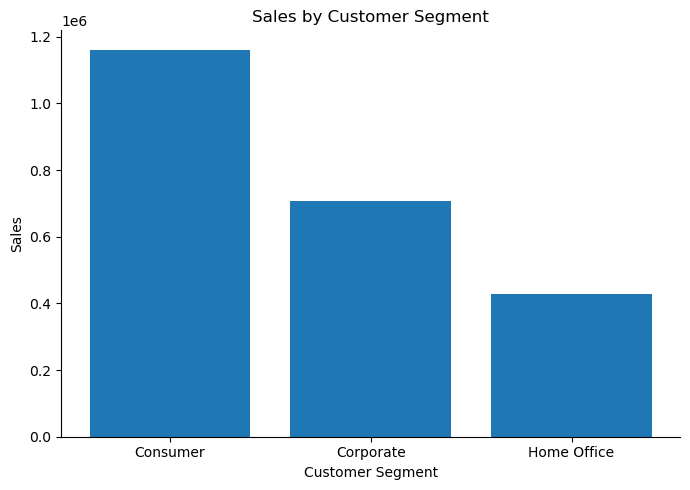

In [35]:
segment_sales = df.groupby("Segment")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(7,5))

plt.bar(
    segment_sales.index,
    segment_sales.values
)

plt.title("Sales by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Sales")

sns.despine()

plt.tight_layout()

plt.show()

####  Business Insight
 Consumer customers generated the highest sales, indicating they are the company's primary revenue source.
#### Business Recommendation
 The company should continue targeting Consumer customers while introducing tailored offers for Corporate and Home Office customers to increase their contribution.

### Business Question 4: How do monthly sales change over time?

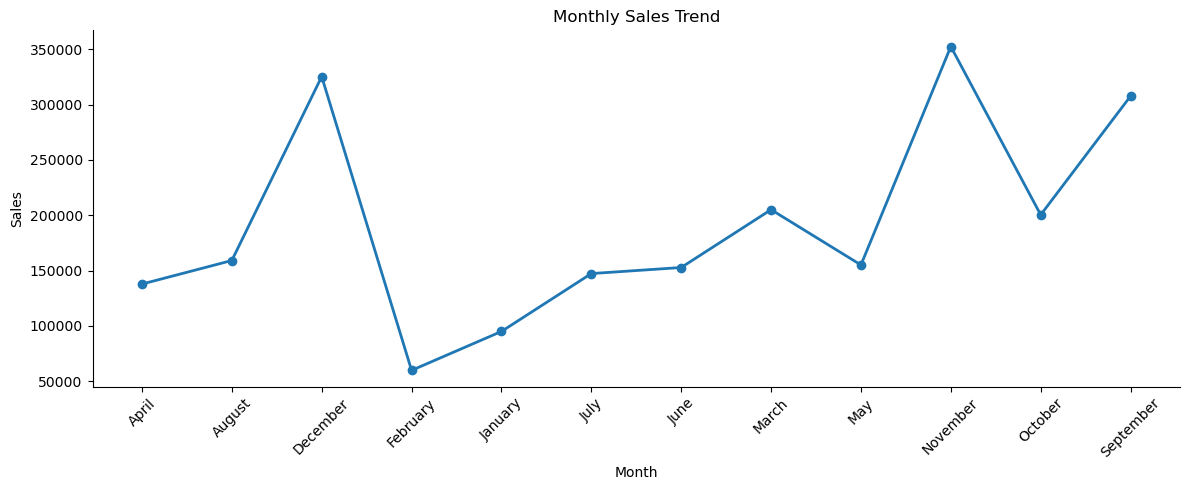

In [36]:
# Monthly Sales
monthly_sales = df.groupby("Month")["Sales"].sum()

plt.figure(figsize=(12,5))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker='o',
    linewidth=2
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.xticks(rotation=45)

sns.despine()

plt.tight_layout()

plt.show()

####  Business Insight
 Sales peaked during November and December, indicating strong seasonal demand.
#### Recommendation
 Increase inventory and marketing before the holiday season

### Business Question 5: Which customer segment contributes the largest share of total sales?

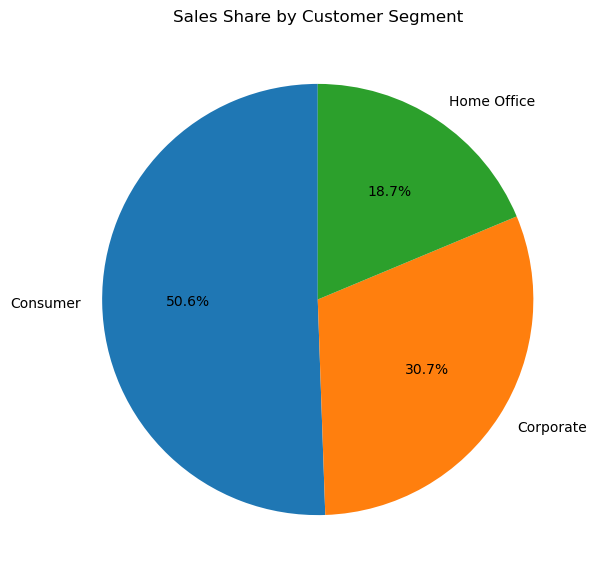

In [37]:
segment_sales = df.groupby("Segment")["Sales"].sum()

plt.figure(figsize=(7,7))

plt.pie(
    segment_sales.values,
    labels=segment_sales.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Sales Share by Customer Segment")

plt.show()

####  Business Insight
Consumer customers contribute over half of total sales.
#### Recommendation
Continue customer retention strategies for Consumer customers while increasing campaigns targeting Corporate and Home Office customers.

### Business Question 6: How are Sales distributed?

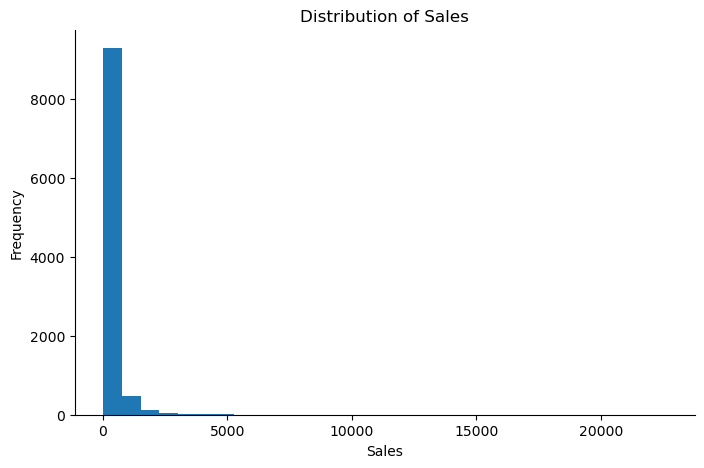

In [38]:
plt.figure(figsize=(8,5))

plt.hist(
    df["Sales"],
    bins=30
)

plt.title("Distribution of Sales")

plt.xlabel("Sales")

plt.ylabel("Frequency")

sns.despine()

plt.show()

#### Business Insight
Most orders have relatively low sales, while a small number of transactions have very high sales.
#### Recommendation
Investigate high-value orders to understand which products and customers generate premium revenue.

### Business Question 7: Are there outliers in Sales?

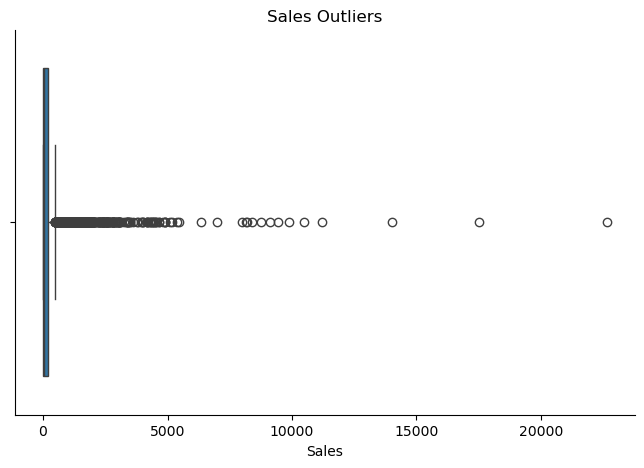

In [39]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df["Sales"]
)

plt.title("Sales Outliers")

sns.despine()

plt.show()

### Business Question 8: Which numerical variables are highly correlated?

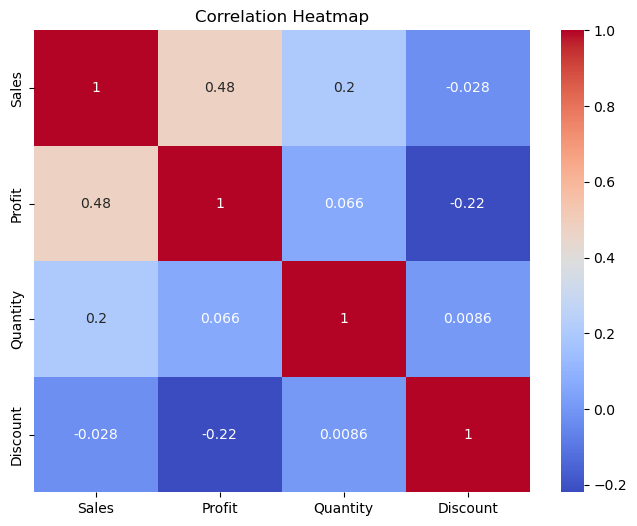

In [40]:
plt.figure(figsize=(8,6))

corr = df[["Sales","Profit","Quantity","Discount"]].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

#### Business Insight
Discount has a negative correlation with Profit, suggesting that higher discounts often reduce profitability.
#### Recommendation
Review discount policies to ensure increased sales do not significantly reduce profits.

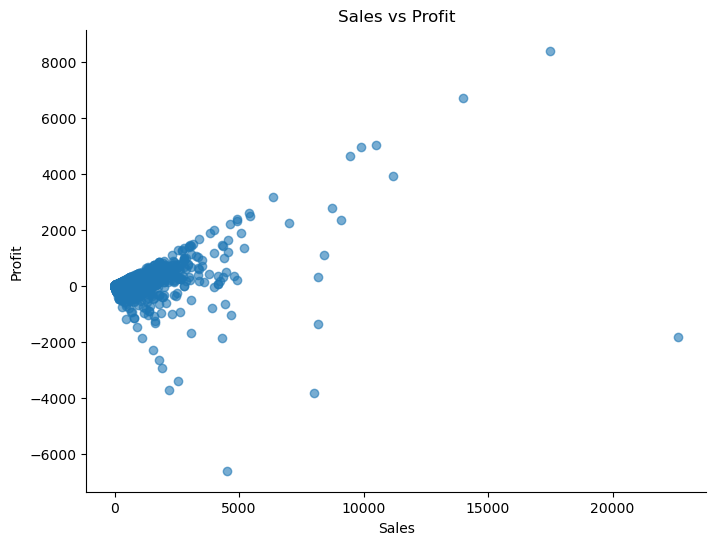

In [41]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["Sales"],
    df["Profit"],
    alpha=0.6
)

plt.title("Sales vs Profit")

plt.xlabel("Sales")

plt.ylabel("Profit")

sns.despine()

plt.show()

#### Business Insight
While higher sales often lead to higher profits, several high-sales orders still resulted in losses due to heavy discounts or other factors.
#### Recommendation
Analyze products with high sales but low or negative profits and optimize pricing or discount strategies.

## Summary – Data Visualization & Storytelling

In this project, I performed **Data Visualization and Storytelling** using the Superstore Sales dataset to answer real business questions. I created various visualizations, including **bar charts, line charts, pie charts, histograms, box plots, scatter plots, and heatmaps**, to analyze sales, profit, customer segments, and regional performance. I applied visualization best practices such as the **Data-Ink Ratio** and the **5-Second Rule** to create clear and effective charts. Each visualization was accompanied by **business insights and actionable recommendations**, transforming raw data into meaningful information for decision-making. This project strengthened my skills in **data analysis, visualization design, and business storytelling using Python**.
